In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [52]:
data = pd.read_excel(r'income_est.xlsx')
data

,account,age,amount,balance,card_present_flag,customer_id,date,first_name,gender,latitude,...,txn_description,bin_age,year,month,day,hour,minute,dow,payment_period,annual_salary
0,ACC-1598451071,26,16.25,35.39,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,POS,20-30,2018,8,1,1,1,Wednesday,7,52856
1,ACC-1598451071,26,14.19,21.20,0.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,SALES-POS,20-30,2018,8,1,1,13,Wednesday,7,52856
2,ACC-1598451071,26,3.25,17.95,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,SALES-POS,20-30,2018,8,1,1,51,Wednesday,7,52856
3,ACC-1598451071,26,14.10,3.85,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,POS,20-30,2018,8,1,8,9,Wednesday,7,52856
4,ACC-1598451071,26,10.67,1006.85,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,POS,20-30,2018,8,1,18,19,Wednesday,7,52856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12038,ACC-2153562714,24,3712.56,9707.77,NaN,CUS-423725039,2018-10-24,Linda,F,-31.88,...,PAY/SALARY,20-30,2018,10,24,14,0,Wednesday,30,45169
12039,ACC-1217063613,27,4863.62,4863.86,NaN,CUS-1739931018,2018-09-26,Kimberly,F,-37.82,...,PAY/SALARY,20-30,2018,9,26,13,0,Wednesday,30,59174
12040,ACC-1217063613,27,4863.62,8905.77,NaN,CUS-1739931018,2018-10-26,Kimberly,F,-37.82,...,PAY/SALARY,20-30,2018,10,26,13,0,Friday,30,59174
12041,ACC-3100725361,25,6107.23,6111.57,NaN,CUS-2178051368,2018-09-26,Ronald,M,-17.03,...,PAY/SALARY,20-30,2018,9,26,15,0,Wednesday,30,74305


In [53]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account,12043,100,ACC-1598451071,578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,12043.0,NaN,NaN,NaN,30.58233,10.046343,18.0,22.0,28.0,38.0,78.0
amount,12043.0,NaN,NaN,NaN,187.933588,592.599934,0.1,16.0,29.0,53.655,8835.98
balance,12043.0,NaN,NaN,NaN,14704.195553,31503.722652,0.24,3158.585,6432.01,12465.945,267128.52
card_present_flag,7717.0,NaN,NaN,NaN,0.802644,0.398029,0.0,1.0,1.0,1.0,1.0
customer_id,12043,100,CUS-2487424745,578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,12043,91,2018-09-28,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_name,12043,80,Michael,746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,12043,2,M,6285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,12043.0,NaN,NaN,NaN,-38.164347,54.622791,-573.0,-37.7,-33.89,-30.75,-12.37


In [54]:
data['payment_period_mean_by_bin_age'] = data.groupby('bin_age')['payment_period'].transform('mean')
data['payment_period_max_by_bin_age'] = data.groupby('bin_age')['payment_period'].transform('max')
data['amount_mean_by_txn_description'] = data.groupby('txn_description')['amount'].transform('mean')
data['amount_max_by_txn_description'] = data.groupby('txn_description')['amount'].transform('max')
data['balance_mean_by_merchant_suburb'] = data.groupby('merchant_suburb')['balance'].transform('mean')
data['balance_max_by_merchant_suburb'] = data.groupby('merchant_suburb')['balance'].transform('max')
data.columns

Index(['account', 'age', 'amount', 'balance', 'card_present_flag',
       'customer_id', 'date', 'first_name', 'gender', 'latitude', 'longitude',
       'merchant_code', 'merchant_id', 'merchant_state', 'merchant_suburb',
       'movement', 'status', 'transaction_id', 'txn_description', 'bin_age',
       'year', 'month', 'day', 'hour', 'minute', 'dow', 'payment_period',
       'annual_salary', 'payment_period_mean_by_bin_age',
       'payment_period_max_by_bin_age', 'amount_mean_by_txn_description',
       'amount_max_by_txn_description', 'balance_mean_by_merchant_suburb',
       'balance_max_by_merchant_suburb'],
      dtype='str')

In [55]:
data.drop(['account', 'customer_id', 'date', 'first_name', 'merchant_id', 'merchant_suburb', 'transaction_id'], axis=1, inplace=True)

In [56]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,12043.0,NaN,NaN,NaN,30.58233,10.046343,18.0,22.0,28.0,38.0,78.0
amount,12043.0,NaN,NaN,NaN,187.933588,592.599934,0.1,16.0,29.0,53.655,8835.98
balance,12043.0,NaN,NaN,NaN,14704.195553,31503.722652,0.24,3158.585,6432.01,12465.945,267128.52
card_present_flag,7717.0,NaN,NaN,NaN,0.802644,0.398029,0.0,1.0,1.0,1.0,1.0
gender,12043,2,M,6285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,12043.0,NaN,NaN,NaN,-38.164347,54.622791,-573.0,-37.7,-33.89,-30.75,-12.37
longitude,12043.0,NaN,NaN,NaN,143.648563,16.669352,114.62,138.69,145.23,151.22,255.0
merchant_code,883.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
merchant_state,7717,8,NSW,2169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
movement,12043,2,debit,11160,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
for i in data.columns:
    if data[i].isnull().sum()>0:
        if pd.api.types.is_numeric_dtype(data[i]):
            data[i] = data[i].fillna(value=data[i].mean())
        else:
            data[i] = data[i].fillna(value=data[i].mode()[0])

In [58]:
data.isnull().sum()

age                                0
amount                             0
balance                            0
card_present_flag                  0
gender                             0
latitude                           0
longitude                          0
merchant_code                      0
merchant_state                     0
movement                           0
status                             0
txn_description                    0
bin_age                            0
year                               0
month                              0
day                                0
hour                               0
minute                             0
dow                                0
payment_period                     0
annual_salary                      0
payment_period_mean_by_bin_age     0
payment_period_max_by_bin_age      0
amount_mean_by_txn_description     0
amount_max_by_txn_description      0
balance_mean_by_merchant_suburb    0
balance_max_by_merchant_suburb     0
d

In [59]:
le = LabelEncoder()

for i in data.columns:
    if not pd.api.types.is_numeric_dtype(data[i]):
       data[i] = le.fit_transform(data[i])

data.describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
age,12043.0,30.582330,10.046343,18.000000,22.000000,28.000000,38.000000,78.000000
amount,12043.0,187.933588,592.599934,0.100000,16.000000,29.000000,53.655000,8835.980000
balance,12043.0,14704.195553,31503.722652,0.240000,3158.585000,6432.010000,12465.945000,267128.520000
card_present_flag,12043.0,0.802644,0.318612,0.000000,0.802644,1.000000,1.000000,1.000000
gender,12043.0,0.521880,0.499542,0.000000,0.000000,1.000000,1.000000,1.000000
latitude,12043.0,-38.164347,54.622791,-573.000000,-37.700000,-33.890000,-30.750000,-12.370000
longitude,12043.0,143.648563,16.669352,114.620000,138.690000,145.230000,151.220000,255.000000
merchant_code,12043.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
merchant_state,12043.0,2.828116,2.304509,0.000000,1.000000,1.000000,6.000000,7.000000
movement,12043.0,0.926679,0.260673,0.000000,1.000000,1.000000,1.000000,1.000000


In [60]:
def evaluate(model,X_train, y_train, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    mae_test = metrics.mean_absolute_error(y_test, y_pred)
    mse_test = metrics.mean_squared_error(y_test, y_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = metrics.r2_score(y_test, y_pred)


    y_pred_train = model.predict(X_train)

    mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
    mse_train = metrics.mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = metrics.r2_score(y_train, y_pred_train)


    results_dict = {
        'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
        'Train': [mae_train, mse_train, rmse_train, r2_train*100],
        'Test': [mae_test, mse_test, rmse_test, r2_test*100]
    }

    results_df = pd.DataFrame(results_dict)
    
    return results_df

In [61]:
y = data['annual_salary']
x = data.drop('annual_salary', axis = 1)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [63]:
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [64]:
evaluate(reg, X_train, y_train, X_test, y_test)

,Metric,Train,Test
0,MAE,217.638535,5.101080e+02
1,MSE,831143.465136,3.550936e+06
2,RMSE,911.670700,1.884393e+03
3,R2,99.859414,9.939543e+01


In [65]:
def plot_feature_importances(model, feature_names):
    
    importances = model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)
   
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.title("Feature Importances")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis() 
    plt.show()
    
    return importance_df

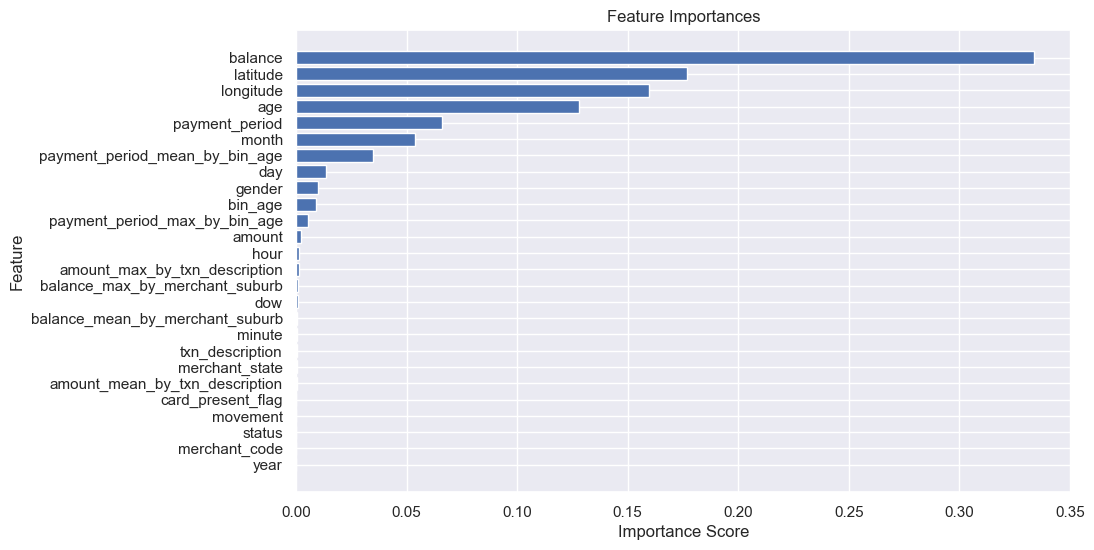

,Feature,Importance
2,balance,0.333746
5,latitude,0.176758
6,longitude,0.159553
0,age,0.128021
19,payment_period,0.065942
14,month,0.053957
20,payment_period_mean_by_bin_age,0.034984
15,day,0.013527
4,gender,0.010066
12,bin_age,0.008852


In [66]:
feature_names = X_train.columns

feature_importance_df = plot_feature_importances(reg, feature_names)

feature_importance_df

In [67]:
feature_importance_df.Feature.tolist()

['balance',
 'latitude',
 'longitude',
 'age',
 'payment_period',
 'month',
 'payment_period_mean_by_bin_age',
 'day',
 'gender',
 'bin_age',
 'payment_period_max_by_bin_age',
 'amount',
 'hour',
 'amount_max_by_txn_description',
 'balance_max_by_merchant_suburb',
 'dow',
 'balance_mean_by_merchant_suburb',
 'minute',
 'txn_description',
 'merchant_state',
 'amount_mean_by_txn_description',
 'card_present_flag',
 'movement',
 'status',
 'merchant_code',
 'year']

In [68]:
reg_selected = RandomForestRegressor(random_state=42)

reg_selected.fit(X_train[['balance',
 'latitude',
 'longitude',
 'age',
 'payment_period',
 'month',
 'payment_period_mean_by_bin_age',
 'day',
 'gender']],y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [69]:
evaluate(reg_selected,X_train[['balance',
 'latitude',
 'longitude',
 'age',
 'payment_period',
 'month',
 'payment_period_mean_by_bin_age',
 'day',
 'gender']],y_train, 
         X_test[['balance',
 'latitude',
 'longitude',
 'age',
 'payment_period',
 'month',
 'payment_period_mean_by_bin_age',
 'day',
 'gender']], y_test)

,Metric,Train,Test
0,MAE,131.942214,3.138327e+02
1,MSE,524963.633351,2.297620e+06
2,RMSE,724.543742,1.515790e+03
3,R2,99.911204,9.960882e+01


In [70]:
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(start = 200, stop = 1000, num = 10)]
max_depth = [int(x) for x in np.linspace(10, 100, num = 11)]


random_grid = {'n_estimators': n_estimators, 
               'max_features': ['sqrt', 0.3, 0.5, None], 
               'max_depth': max_depth, 
               'min_samples_split': [20,50], 
               'min_samples_leaf': [5, 8, 10]} 

In [71]:
rf_random = RandomizedSearchCV(estimator = reg, param_distributions = random_grid, n_iter = 10, cv = 3, verbose=1, random_state=42, n_jobs = -1)

rf_random.fit(X_train[['balance',
 'latitude',
 'longitude',
 'age',
 'payment_period',
 'month',
 'payment_period_mean_by_bin_age',
 'day',
 'gender']], y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 19, ...], 'max_features': ['sqrt', 0.3, ...], 'min_samples_leaf': [5, 8, ...], 'min_samples_split': [20, 50], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [72]:
rf_random.best_params_

{'n_estimators': 1000,
 'min_samples_split': 20,
 'min_samples_leaf': 5,
 'max_features': 'sqrt',
 'max_depth': 91}

In [73]:
optimized_model = rf_random.best_estimator_

evaluate(optimized_model, X_train[['balance',
 'latitude',
 'longitude',
 'age',
 'payment_period',
 'month',
 'payment_period_mean_by_bin_age',
 'day',
 'gender']],y_train, 
  X_test[['balance',
 'latitude',
 'longitude',
 'age',
 'payment_period',
 'month',
 'payment_period_mean_by_bin_age',
 'day',
 'gender']], y_test)


,Metric,Train,Test
0,MAE,6.922538e+02,8.602892e+02
1,MSE,3.120470e+06,4.418844e+06
2,RMSE,1.766485e+03,2.102105e+03
3,R2,9.947218e+01,9.924766e+01


# Deployment

In [74]:
data_deploy = pd.read_excel(r'income_deploy.xlsx')
data_deploy

,account,age,amount,balance,card_present_flag,customer_id,date,first_name,gender,latitude,...,transaction_id,txn_description,bin_age,year,month,day,hour,minute,dow,payment_period
0,ACC-4258502723,24,116.26,4241.76,1.0,CUS-3378712515,2018-10-08,Kimberly,F,-37.74,...,b1e504ecf44840abb3a48b4ab8510f00,SALES-POS,20-30,2018,10,8,13,33,Monday,7
1,ACC-4258502723,24,14.18,5122.49,1.0,CUS-3378712515,2018-10-11,Kimberly,F,-37.74,...,dfa272cc57334c7ca87f61a258cb5b90,SALES-POS,20-30,2018,10,11,12,7,Thursday,7
2,ACC-1279356312,44,17.40,5906.28,1.0,CUS-1892177589,2018-08-29,Tyler,M,-37.73,...,d87dc36be2a2414784dd1c84ced28c71,POS,40-50,2018,8,29,9,43,Wednesday,14
3,ACC-1344825761,46,22.00,15729.73,NaN,CUS-1499065773,2018-08-17,Sarah,F,-33.91,...,4d250222351c4fdb90f7a3085f881276,PAYMENT,40-50,2018,8,17,14,0,Friday,14
4,ACC-2171593283,19,33.00,11168.81,NaN,CUS-2317998716,2018-09-06,Fernando,M,-36.04,...,a4154a29a5d642ca9643b402a87e39d3,PAYMENT,<20,2018,9,6,5,0,Thursday,14
5,ACC-240804743,29,56.00,7651.46,NaN,CUS-261674136,2018-08-29,Kenneth,M,-30.75,...,010cfffccf6c4fefb0a7d0b88a6d68da,PAYMENT,20-30,2018,8,29,14,0,Wednesday,14
6,ACC-3954677887,47,24.00,1161.91,NaN,CUS-3716701010,2018-08-11,Ruth,F,-32.28,...,ec40f0d4f9be46f18d93bf86971f38dc,PAYMENT,40-50,2018,8,11,23,0,Saturday,7
7,ACC-2920611728,69,39.12,5215.77,1.0,CUS-1388323263,2018-09-12,Tyler,M,-37.76,...,9c4b758fc15c4aaca329872b206da045,SALES-POS,60-70,2018,9,12,1,12,Wednesday,7
8,ACC-2305712452,18,18.04,2390.88,1.0,CUS-1842679196,2018-08-31,Debra,F,-34.89,...,03a5e32154914752a4316fa6663633b6,SALES-POS,<20,2018,8,31,21,19,Friday,7
9,ACC-1710017148,19,16.18,1609.16,1.0,CUS-883482547,2018-08-01,Michelle,F,-34.01,...,927d07bdbeb743ebab2865f86132cd99,POS,<20,2018,8,1,14,37,Wednesday,14


In [75]:
data_deploy.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account,30,27,ACC-4258502723,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,30.0,NaN,NaN,NaN,31.6,12.48613,18.0,22.0,26.5,40.0,69.0
amount,30.0,NaN,NaN,NaN,280.705667,583.629855,3.67,22.5,39.515,101.0,2280.36
balance,30.0,NaN,NaN,NaN,5160.872,3397.26541,134.78,2400.68,4818.13,7146.985,15729.73
card_present_flag,16.0,NaN,NaN,NaN,0.875,0.341565,0.0,1.0,1.0,1.0,1.0
customer_id,30,27,CUS-3378712515,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,30,28,2018-10-08,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_name,30,25,Kimberly,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,30,2,M,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,30.0,NaN,NaN,NaN,-68.681667,137.199734,-573.0,-37.7375,-33.935,-31.925,-12.37


In [79]:
data_deploy['payment_period_mean_by_bin_age'] = data_deploy.groupby('bin_age')['payment_period'].transform('mean')

In [80]:
data_deploy['gender'] = le.fit_transform(data_deploy['gender'])

In [81]:
data_deploy.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account,30,27,ACC-4258502723,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,30.0,NaN,NaN,NaN,31.6,12.48613,18.0,22.0,26.5,40.0,69.0
amount,30.0,NaN,NaN,NaN,280.705667,583.629855,3.67,22.5,39.515,101.0,2280.36
balance,30.0,NaN,NaN,NaN,5160.872,3397.26541,134.78,2400.68,4818.13,7146.985,15729.73
card_present_flag,16.0,NaN,NaN,NaN,0.875,0.341565,0.0,1.0,1.0,1.0,1.0
customer_id,30,27,CUS-3378712515,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,30,28,2018-10-08,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_name,30,25,Kimberly,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,30.0,NaN,NaN,NaN,0.533333,0.507416,0.0,0.0,1.0,1.0,1.0
latitude,30.0,NaN,NaN,NaN,-68.681667,137.199734,-573.0,-37.7375,-33.935,-31.925,-12.37


In [82]:
inputs_deploy = data_deploy[['balance',
 'latitude',
 'longitude',
 'age',
 'payment_period',
 'month',
 'payment_period_mean_by_bin_age',
 'day',
 'gender']]

In [83]:
data_deploy['Annual Salary'] = rf_random.predict(inputs_deploy)
data_deploy

,account,age,amount,balance,card_present_flag,customer_id,date,first_name,gender,latitude,...,bin_age,year,month,day,hour,minute,dow,payment_period,payment_period_mean_by_bin_age,Annual Salary
0,ACC-4258502723,24,116.26,4241.76,1.0,CUS-3378712515,2018-10-08,Kimberly,0,-37.74,...,20-30,2018,10,8,13,33,Monday,7,10.500000,62705.971224
1,ACC-4258502723,24,14.18,5122.49,1.0,CUS-3378712515,2018-10-11,Kimberly,0,-37.74,...,20-30,2018,10,11,12,7,Thursday,7,10.500000,62725.679375
2,ACC-1279356312,44,17.40,5906.28,1.0,CUS-1892177589,2018-08-29,Tyler,1,-37.73,...,40-50,2018,8,29,9,43,Wednesday,14,9.800000,83851.343519
3,ACC-1344825761,46,22.00,15729.73,NaN,CUS-1499065773,2018-08-17,Sarah,0,-33.91,...,40-50,2018,8,17,14,0,Friday,14,9.800000,84370.092636
4,ACC-2171593283,19,33.00,11168.81,NaN,CUS-2317998716,2018-09-06,Fernando,1,-36.04,...,<20,2018,9,6,5,0,Thursday,14,11.666667,67432.614691
5,ACC-240804743,29,56.00,7651.46,NaN,CUS-261674136,2018-08-29,Kenneth,1,-30.75,...,20-30,2018,8,29,14,0,Wednesday,14,10.500000,96129.754461
6,ACC-3954677887,47,24.00,1161.91,NaN,CUS-3716701010,2018-08-11,Ruth,0,-32.28,...,40-50,2018,8,11,23,0,Saturday,7,9.800000,81769.942555
7,ACC-2920611728,69,39.12,5215.77,1.0,CUS-1388323263,2018-09-12,Tyler,1,-37.76,...,60-70,2018,9,12,1,12,Wednesday,7,7.000000,54462.842024
8,ACC-2305712452,18,18.04,2390.88,1.0,CUS-1842679196,2018-08-31,Debra,0,-34.89,...,<20,2018,8,31,21,19,Friday,7,11.666667,40946.979197
9,ACC-1710017148,19,16.18,1609.16,1.0,CUS-883482547,2018-08-01,Michelle,0,-34.01,...,<20,2018,8,1,14,37,Wednesday,14,11.666667,92768.241034
